# Sensitivity Test: Figure 4 & Table 1
Tests sensitivity of correlation significance, trend sign/slope, and P1/P2 differences to the choice of period years.

## Imports

In [1]:
from datetime import datetime

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import ks_2samp, pearsonr, weibull_min

## Filenames

In [2]:
ts_or_td = "TD"

start = 1940
stop  = 2023
nens  = 10

namelist_f = [
    [
        f"/glade/work/smhenry/NeuralGCM/data/tracks/factual/ens{X}_{YYYY}_JASO_TC_tracks_factual.txt"
        for X in range(1, nens + 1)
    ]
    for YYYY in range(start, stop + 1)
]

## Counting functions

In [3]:
def count_NA(file):
    count = 0
    in_TC = False
    is_in_NA = False
    with open(file, "r") as df:
        for line in df:
            if line.startswith("start"):
                if is_in_NA:
                    count += 1
                is_in_NA = False
                in_TC = True
            elif in_TC:
                data = line.split()
                if len(data) >= 4:
                    lon = float(data[2])
                    lat = float(data[3])
                    if (
                        (285 <= lon <= 360 and 0 <= lat <= 50)
                        or (276 <= lon < 285 and 10 <= lat <= 50)
                        or (262 <= lon < 276 and 16.5 <= lat <= 50)
                    ):
                        is_in_NA = True
        if is_in_NA:
            count += 1
    return count


def count_NWP(file):
    count = 0
    in_TC = False
    is_in_NWP = False
    with open(file, "r") as df:
        for line in df:
            if line.startswith("start"):
                if is_in_NWP:
                    count += 1
                is_in_NWP = False
                in_TC = True
            elif in_TC:
                data = line.split()
                if len(data) >= 4:
                    lon = float(data[2])
                    lat = float(data[3])
                    if 100 <= lon <= 180 and 0 <= lat <= 50:
                        is_in_NWP = True
        if is_in_NWP:
            count += 1
    return count


def count_NEP(file):
    count = 0
    in_TC = False
    is_in_NEP = False
    with open(file, "r") as df:
        for line in df:
            if line.startswith("start"):
                if is_in_NEP:
                    count += 1
                is_in_NEP = False
                in_TC = True
            elif in_TC:
                data = line.split()
                if len(data) >= 4:
                    lon = float(data[2])
                    lat = float(data[3])
                    if (
                        (275 <= lon <= 284 and 0 <= lat <= 10)
                        or (260 <= lon < 275 and 0 <= lat <= 16.5)
                        or (180 <= lon < 260 and 0 <= lat <= 50)
                    ):
                        is_in_NEP = True
        if is_in_NEP:
            count += 1
    return count


def count_TCs_ibtracs(year, basin, type):
    df = pd.read_csv(f"/glade/work/smhenry/NeuralGCM/data/ibtracs/IBTrACS_{year}_JASO.csv")
    df["time"] = pd.to_datetime(df["time"])
    storm_durations = df.groupby("stormid")["time"].agg(
        lambda x: (x.max() - x.min()).total_seconds() / 3600
    )
    valid_storms = storm_durations[storm_durations >= 54].index
    df = df[df["stormid"].isin(valid_storms) & df["stormid"].str.contains(basin)]
    type_dict = {
        "TD": "HU|HR|TY|ST|TS|TC|SS|TD|SD",
        "TS": "HU|HR|TY|ST|TS|TC|SS",
        "HU": "HU|HR|TY|ST",
        "TY": "HU|HR|TY|ST",
    }
    if type in type_dict:
        df = df[df["type"].str.contains(type_dict[type])]
    return df["stormid"].nunique()


def count_NA_mo(file, mo):
    count = 0
    in_TC = False
    is_in_NA = False
    in_mo = False
    with open(file, "r") as df:
        for line in df:
            if line.startswith("start"):
                if is_in_NA and in_mo:
                    count += 1
                is_in_NA = False
                in_TC = True
                in_mo = line.split()[3] == mo
            elif in_TC:
                data = line.split()
                if len(data) >= 4:
                    lon = float(data[2])
                    lat = float(data[3])
                    if (
                        (285 <= lon <= 360 and 0 <= lat <= 50)
                        or (276 <= lon < 285 and 10 <= lat <= 50)
                        or (262 <= lon < 276 and 16.5 <= lat <= 50)
                    ):
                        is_in_NA = True
        if is_in_NA and in_mo:
            count += 1
    return count


def count_NWP_mo(file, mo):
    count = 0
    in_TC = False
    is_in_NWP = False
    in_mo = None
    with open(file, "r") as df:
        for line in df:
            if line.startswith("start"):
                if is_in_NWP and in_mo:
                    count += 1
                is_in_NWP = False
                in_TC = True
                in_mo = line.split()[3] == mo
            elif in_TC:
                data = line.split()
                if len(data) >= 4:
                    lon = float(data[2])
                    lat = float(data[3])
                    if 100 <= lon <= 180 and 0 <= lat <= 50:
                        is_in_NWP = True
        if is_in_NWP and in_mo:
            count += 1
    return count


def count_NEP_mo(file, mo):
    count = 0
    in_TC = False
    is_in_NEP = False
    in_mo = None
    with open(file, "r") as df:
        for line in df:
            if line.startswith("start"):
                if is_in_NEP and in_mo:
                    count += 1
                is_in_NEP = False
                in_TC = True
                in_mo = line.split()[3] == mo
            elif in_TC:
                data = line.split()
                if len(data) >= 4:
                    lon = float(data[2])
                    lat = float(data[3])
                    if (
                        (275 <= lon <= 284 and 0 <= lat <= 10)
                        or (260 <= lon < 275 and 0 <= lat <= 16.5)
                        or (180 <= lon < 260 and 0 <= lat <= 50)
                    ):
                        is_in_NEP = True
        if is_in_NEP and in_mo:
            count += 1
    return count


def count_TCs_ibtracs_mo(year, mo, basin, type):
    df = pd.read_csv(f"/glade/work/smhenry/NeuralGCM/data/ibtracs/IBTrACS_{year}_JASO.csv")
    df["time"] = pd.to_datetime(df["time"])
    storm_durations = df.groupby("stormid")["time"].agg(
        lambda x: (x.max() - x.min()).total_seconds() / 3600
    )
    valid_storms = storm_durations[storm_durations >= 54].index
    df = df[df["stormid"].isin(valid_storms) & df["stormid"].str.contains(basin)]
    type_dict = {
        "TD": "HU|HR|TY|ST|TS|TC|SS|TD|SD",
        "TS": "HU|HR|TY|ST|TS|TC|SS",
        "HU": "HU|HR|TY|ST",
        "TY": "HU|HR|TY|ST",
    }
    if type in type_dict:
        df = df[df["type"].str.contains(type_dict[type])]
    storm_start_month = df.groupby("stormid")["time"].min().dt.month
    storms_starting_in_month = storm_start_month[storm_start_month == mo].index
    df = df[df["stormid"].isin(storms_starting_in_month)]
    return df["stormid"].nunique()

## Processing functions

In [4]:
def process_counts(namelist, basin, start, exclude=None, ens=False, min_max=False):
    nyr = np.shape(namelist)[0]
    _nens = np.shape(namelist)[1] if ens else 1
    counts = np.zeros((nyr, _nens))

    for iyr in range(nyr):
        if ens:
            for iens in range(_nens):
                skip = exclude and any(
                    iyr == (e[0] - start) and iens == (e[1] - 1) for e in exclude
                )
                if skip:
                    counts[iyr][iens] = np.nan
                else:
                    fn = {"NA": count_NA, "NWP": count_NWP, "NEP": count_NEP}.get(basin)
                    counts[iyr][iens] = fn(namelist[iyr][iens]) if fn else np.nan
        else:
            fn = {"NA": count_NA, "NWP": count_NWP, "NEP": count_NEP}.get(basin)
            counts[iyr][0] = fn(namelist[iyr]) if fn else np.nan

    count   = np.array([np.nanmean(counts[i]) for i in range(nyr)]).reshape(-1, 1)
    twenty  = np.array([np.nanpercentile(counts[i], 20) for i in range(nyr)]).reshape(-1, 1)
    eighty  = np.array([np.nanpercentile(counts[i], 80) for i in range(nyr)]).reshape(-1, 1)
    mn = np.array([np.nanmin(counts[i]) for i in range(nyr)]).reshape(-1, 1) if min_max else None
    mx = np.array([np.nanmax(counts[i]) for i in range(nyr)]).reshape(-1, 1) if min_max else None
    return count, twenty, eighty, mn, mx


def process_counts_mo(namelist, basin, start, mo, exclude=None, nens=1, min_max=False):
    nyr = np.shape(namelist)[0]
    counts = np.zeros((nyr, nens))

    fn_map = {"NA": count_NA_mo, "NWP": count_NWP_mo, "NEP": count_NEP_mo}

    for iyr in range(nyr):
        for iens in range(nens):
            skip = exclude and any(
                iyr == (e[0] - start) and iens == (e[1] - 1) for e in exclude
            )
            if skip:
                counts[iyr][iens] = np.nan
            else:
                fn = fn_map.get(basin)
                counts[iyr][iens] = fn(namelist[iyr][iens], mo) if fn else np.nan

    count   = np.array([np.nanmean(counts[i]) for i in range(nyr)]).reshape(-1, 1)
    twenty  = np.array([np.nanpercentile(counts[i], 20) for i in range(nyr)]).reshape(-1, 1)
    eighty  = np.array([np.nanpercentile(counts[i], 80) for i in range(nyr)]).reshape(-1, 1)
    mn = np.array([np.nanmin(counts[i]) for i in range(nyr)]).reshape(-1, 1) if min_max else None
    mx = np.array([np.nanmax(counts[i]) for i in range(nyr)]).reshape(-1, 1) if min_max else None
    return count, twenty, eighty, mn, mx

## Lifetime functions

In [5]:
def _get_lifetime(file, basin_check):
    tc_tracks = {}
    current_tc_id = None
    with open(file, "r") as f:
        for line in f:
            if line.startswith("start"):
                current_tc_id = len(tc_tracks)
                tc_tracks[current_tc_id] = []
            else:
                data = line.split()
                if len(data) >= 10:
                    lon = float(data[2])
                    lat = float(data[3])
                    year, month, day, hour = map(int, data[6:10])
                    tc_tracks[current_tc_id].append((lon, lat, datetime(year, month, day, hour)))
    lifetimes = []
    for track in tc_tracks.values():
        if track and basin_check(track[0][0], track[0][1]):
            lt = (track[-1][2] - track[0][2]).total_seconds() / 3600 / 24
            lifetimes.append(int(lt))
    return lifetimes


def get_lifetime_NA(file):
    return _get_lifetime(file, lambda lon, lat: (
        (285 <= lon <= 360 and lat >= 0)
        or (276 <= lon <= 285 and lat >= 10)
        or (262 <= lon <= 276 and lat >= 16.5)
    ))


def get_lifetime_NEP(file):
    return _get_lifetime(file, lambda lon, lat: (
        (275 <= lon <= 284 and lat <= 10)
        or (260 <= lon <= 275 and lat <= 16.5)
        or (180 <= lon <= 260 and lat >= 0)
    ))


def get_lifetime_NWP(file):
    return _get_lifetime(file, lambda lon, lat: 100 <= lon <= 180 and lat >= 0)


def get_lifetime_IBTrACS(year, basin, type):
    df = pd.read_csv(f"/glade/work/smhenry/NeuralGCM/data/ibtracs/IBTrACS_{year}_JASO.csv")
    df["time"] = pd.to_datetime(df["time"])
    storm_durations = df.groupby("stormid")["time"].agg(
        lambda x: (x.max() - x.min()).total_seconds() / 3600
    )
    valid_storms = storm_durations[storm_durations >= 54].index
    df_valid = df[df["stormid"].isin(valid_storms) & df["stormid"].str.contains(basin)]
    type_dict = {
        ts_or_td: "HU|HR|TY|ST|TS|TC|SS|TD|SD",
        "TS": "HU|HR|TY|ST|TS|TC|SS",
        "HU": "HU|HR|TY|ST",
        "TY": "HU|HR|TY|ST",
    }
    if type in type_dict:
        df_type = df_valid[df_valid["type"].str.contains(type_dict[type])]
    lifetimes = df_type.groupby("stormid")["time"].agg(
        lambda x: (x.max() - x.min()).total_seconds() / 3600 / 24
    ).values
    if len(lifetimes) > 0:
        lifetimes = lifetimes[lifetimes > 54 / 24]
    return lifetimes


values = np.arange(54 / 24, 24 + 54 / 24 + 1 / 24, 1 / 24)

## Trend utility

In [6]:
def add_trend_line(ax, x, y, color, label=None, linewidth=2, linestyle="-", zorder=None):
    coeffs = np.polyfit(x, y, 1)
    trend = np.poly1d(coeffs)(x)
    ax.plot(x, trend, color=color, label=label, linewidth=linewidth,
            linestyle=linestyle, zorder=zorder)


def trend_slope_and_pvalue(x, y):
    """Return (slope, p-value) for a linear trend via Mann-Kendall / polyfit."""
    from scipy.stats import linregress
    mask = ~np.isnan(y)
    if mask.sum() < 3:
        return np.nan, np.nan
    slope, intercept, r, p, se = linregress(x[mask], np.array(y)[mask])
    return slope, p

## Process full-record data (counts + IBTrACS obs)

In [7]:
f_exclude = [
    [1992, 3],
    [2005, 17],
    [2012, 14],
    [2017, 3],
    [2017, 12],
    [2017, 13],
    [2021, 16],
]

f_ensmean_count_NA,  f_twenty_NA,  f_eighty_NA,  f_min_NA,  f_max_NA  = process_counts(
    namelist_f, "NA",  start, ens=True, min_max=True, exclude=f_exclude)
f_ensmean_count_NWP, f_twenty_NWP, f_eighty_NWP, f_min_NWP, f_max_NWP = process_counts(
    namelist_f, "NWP", start, ens=True, min_max=True, exclude=f_exclude)
f_ensmean_count_NEP, f_twenty_NEP, f_eighty_NEP, f_min_NEP, f_max_NEP = process_counts(
    namelist_f, "NEP", start, ens=True, min_max=True, exclude=f_exclude)

f_ensmean_count_NA  = f_ensmean_count_NA.flatten()
f_ensmean_count_NWP = f_ensmean_count_NWP.flatten()
f_ensmean_count_NEP = f_ensmean_count_NEP.flatten()

In [8]:
obs_TC_count_NA  = []
obs_HR_count_NA  = []
obs_TC_count_NEP = []
obs_TY_count_NEP = []
obs_TC_count_NWP = []
obs_TY_count_NWP = []

for year in range(start, stop + 1):
    if year < 1949:
        obs_TC_count_NEP.append(np.nan)
        obs_TY_count_NEP.append(np.nan)
        if year < 1945:
            obs_TC_count_NWP.append(np.nan)
            obs_TY_count_NWP.append(np.nan)
        else:
            obs_TC_count_NWP.append(count_TCs_ibtracs(year, "WP", ts_or_td))
            obs_TY_count_NWP.append(count_TCs_ibtracs(year, "WP", "TY"))
    else:
        obs_TC_count_NEP.append(count_TCs_ibtracs(year, "EP", ts_or_td))
        obs_TY_count_NEP.append(count_TCs_ibtracs(year, "EP", "TY"))
        obs_TC_count_NWP.append(count_TCs_ibtracs(year, "WP", ts_or_td))
        obs_TY_count_NWP.append(count_TCs_ibtracs(year, "WP", "TY"))
    obs_TC_count_NA.append(count_TCs_ibtracs(year, "AL", ts_or_td))
    obs_HR_count_NA.append(count_TCs_ibtracs(year, "AL", "HU"))

yrlist = np.arange(start, stop + 1)

---
# Table 1 — Correlation sensitivity
Tests whether correlations between factual ensemble mean and IBTrACS are significant, with asterisks for p<0.05 (*) and p<0.01 (**).

In [9]:
# Correlation year ranges
corr_yr_list = [[1940, 2023], [1949, 2023], [1949, 1985], [1987, 2023], [1970, 2023]]

basins = {
    "NA TC":  (f_ensmean_count_NA,  obs_TC_count_NA),
    "NA HR":  (f_ensmean_count_NA,  obs_HR_count_NA),
    "NEP TC": (f_ensmean_count_NEP, obs_TC_count_NEP),
    "NEP HR": (f_ensmean_count_NEP, obs_TY_count_NEP),
    "NWP TC": (f_ensmean_count_NWP, obs_TC_count_NWP),
    "NWP HR": (f_ensmean_count_NWP, obs_TY_count_NWP),
}

corr_rows = {}
for label, (f_arr, obs_arr) in basins.items():
    row = []
    for yr1, yr2 in corr_yr_list:
        i1 = np.where(yrlist == yr1)[0][0]
        i2 = np.where(yrlist == yr2)[0][0]
        f_sub   = f_arr[i1:i2+1]
        obs_sub = np.array(obs_arr)[i1:i2+1]
        # Drop NaNs
        mask = ~np.isnan(f_sub) & ~np.isnan(obs_sub)
        if mask.sum() < 3:
            row.append("N/A")
        else:
            r, p = pearsonr(f_sub[mask], obs_sub[mask])
            sig = "**" if p < 0.01 else ("*" if p < 0.05 else "")
            row.append(f"{r:.2f}{sig}")
    corr_rows[label] = row

corr_cols = [f"{yr1}–{yr2}" for yr1, yr2 in corr_yr_list]
df_corr = pd.DataFrame(corr_rows, index=corr_cols).T
print("Table 1 — Pearson correlations (* p<0.05, ** p<0.01)")
df_corr

Table 1 — Pearson correlations (* p<0.05, ** p<0.01)


,1940–2023,1949–2023,1949–1985,1987–2023,1970–2023
NA TC,0.45**,0.45**,0.32,0.60**,0.44**
NA HR,0.60**,0.64**,0.64**,0.60**,0.67**
NEP TC,0.41**,0.41**,0.30,0.36*,0.29*
NEP HR,0.47**,0.47**,0.26,0.49**,0.43**
NWP TC,0.27*,0.36**,0.32,0.32,0.33*
NWP HR,0.17,0.23*,0.17,0.32,0.31*


---
# Table 2 — Trend slopes
Linear trend slopes (TCs per year) for IBTrACS and Factual ensemble mean, per basin, for three time windows.

In [10]:
trend_windows = [[1949, 2023], [1965, 2023], [1980, 2023]]

trend_basins = {
    "NA":  {"obs": obs_TC_count_NA,  "f": f_ensmean_count_NA},
    "NEP": {"obs": obs_TC_count_NEP, "f": f_ensmean_count_NEP},
    "NWP": {"obs": obs_TC_count_NWP, "f": f_ensmean_count_NWP},
}

trend_rows = []
for basin, arrs in trend_basins.items():
    for src_label, arr in [("IBTrACS", arrs["obs"]), ("Factual", arrs["f"])]:
        row = {"Basin": basin, "Source": src_label}
        for yr1, yr2 in trend_windows:
            i1 = np.where(yrlist == yr1)[0][0]
            i2 = np.where(yrlist == yr2)[0][0]
            x = yrlist[i1:i2+1]
            y = np.array(arr)[i1:i2+1]
            slope, p = trend_slope_and_pvalue(x, y)
            sig = "**" if p < 0.01 else ("*" if p < 0.05 else "")
            col = f"{yr1}–{yr2}"
            row[col] = f"{slope:.3f}{sig}" if not np.isnan(slope) else "N/A"
        trend_rows.append(row)

df_trend = pd.DataFrame(trend_rows).set_index(["Basin", "Source"])
print("Table 2 — Trend slopes [TCs yr⁻¹] (* p<0.05, ** p<0.01)")
df_trend

Table 2 — Trend slopes [TCs yr⁻¹] (* p<0.05, ** p<0.01)


1949–2023 1965–2023 1980–2023
Basin Source                               
NA    IBTrACS     0.017    -0.020     0.052
      Factual    0.027*   0.054**     0.048
NEP   IBTrACS   0.111**     0.003    -0.086
      Factual   0.047**   0.050**    0.067*
NWP   IBTrACS     0.030    -0.036   -0.108*
      Factual   0.039**     0.034    0.067*

---
# Figure — Sensitivity of lifetime & seasonality to P1/P2 choice
Three P1/P2 pairs:
- **Pair A**: P1=1949–1980, P2=1992–2023
- **Pair B**: P1=1955–1985, P2=1987–2017
- **Pair C**: P1=1955–1980, P2=1992–2017

Same layout as Figure 4 (3×3 grid), repeated for each pair (one figure per pair, 3 figures total).

In [11]:
PERIOD_PAIRS = [
    {"label": "A", "p1_start": 1949, "p1_stop": 1980, "p2_start": 1992, "p2_stop": 2023},
    {"label": "B", "p1_start": 1955, "p1_stop": 1985, "p2_start": 1987, "p2_stop": 2017},
    {"label": "C", "p1_start": 1955, "p1_stop": 1980, "p2_start": 1992, "p2_stop": 2017},
    {"label": "Z", "p1_start": 1949, "p1_stop": 1985, "p2_start": 1987, "p2_stop": 2023},
]


def compute_period_data(p1_start, p1_stop, p2_start, p2_stop):
    """Compute all data needed for one figure panel set."""
    i_p1_start = np.where(yrlist == p1_start)[0].item()
    i_p1_stop  = np.where(yrlist == p1_stop)[0].item()
    i_p2_start = np.where(yrlist == p2_start)[0].item()
    i_p2_stop  = np.where(yrlist == p2_stop)[0].item()

    mo_list_str = ["7", "8", "9", "10"]
    mo_list_int = [7, 8, 9, 10]

    # --- Factual monthly fractions ---
    mo_count_f = {b: {"p1": [], "p2": []} for b in ["NA", "NWP", "NEP"]}
    f_count_map = {"NA": f_ensmean_count_NA, "NWP": f_ensmean_count_NWP, "NEP": f_ensmean_count_NEP}

    for mo in mo_list_str:
        for basin in ["NA", "NWP", "NEP"]:
            for period, (i_s, i_e) in [("p1", (i_p1_start, i_p1_stop)),
                                       ("p2", (i_p2_start, i_p2_stop))]:
                c, _, _, _, _ = process_counts_mo(
                    namelist_f[i_s:i_e][:], basin, start, mo,
                    nens=10, min_max=False, exclude=f_exclude
                )
                frac = c.flatten() / f_count_map[basin][i_s:i_e]
                mo_count_f[basin][period].append(frac.flatten())

    # --- Observed monthly fractions ---
    obs_mo = {b: {"p1": [[] for _ in mo_list_int],
                  "p2": [[] for _ in mo_list_int]} for b in ["NA", "NWP", "NEP"]}
    basin_map_ibtracs = {"NA": "AL", "NWP": "WP", "NEP": "EP"}
    obs_count_map = {"NA": obs_TC_count_NA, "NWP": obs_TC_count_NWP, "NEP": obs_TC_count_NEP}

    for year in range(start, stop + 1):
        for basin in ["NA", "NWP", "NEP"]:
            if p1_start <= year <= p1_stop:
                for i, mo in enumerate(mo_list_int):
                    obs_mo[basin]["p1"][i].append(
                        count_TCs_ibtracs_mo(year, mo, basin_map_ibtracs[basin], ts_or_td))
            elif p2_start <= year <= p2_stop:
                for i, mo in enumerate(mo_list_int):
                    obs_mo[basin]["p2"][i].append(
                        count_TCs_ibtracs_mo(year, mo, basin_map_ibtracs[basin], ts_or_td))

    # Normalise observed monthly counts
    for basin in ["NA", "NWP", "NEP"]:
        obs_arr = np.array(obs_count_map[basin])
        obs_mo[basin]["p1"] = (
            np.array(obs_mo[basin]["p1"]) /
            obs_arr[i_p1_start:i_p1_stop + 1].T
        )
        obs_mo[basin]["p2"] = (
            np.array(obs_mo[basin]["p2"]) /
            obs_arr[i_p2_start:i_p2_stop + 1].T
        )

    # --- Lifetimes ---
    bins = np.arange(0, 22, 1)
    lt_data = {}
    get_lt_map = {"NA": get_lifetime_NA, "NWP": get_lifetime_NWP, "NEP": get_lifetime_NEP}
    ibtracs_map = {"NA": "AL", "NWP": "WP", "NEP": "EP"}

    for basin in ["NA", "NWP", "NEP"]:
        f_p1, f_p2, obs_p1, obs_p2 = [], [], [], []
        f_all, obs_all = [], []

        for iyr, yr in enumerate(range(start, stop + 1)):
            in_p1 = p1_start <= yr <= p1_stop
            in_p2 = p2_start <= yr <= p2_stop

            for iens in range(nens):
                skip = any(iyr == (e[0] - start) and iens == (e[1] - 1) for e in f_exclude)
                if not skip:
                    lts = get_lt_map[basin](namelist_f[iyr][iens])
                    f_all.extend(lts)
                    if in_p1:
                        f_p1.extend(lts)
                    elif in_p2:
                        f_p2.extend(lts)

            obs_lts = get_lifetime_IBTrACS(yr, ibtracs_map[basin], ts_or_td)
            obs_all.extend(obs_lts)
            if in_p1:
                obs_p1.extend(obs_lts)
            elif in_p2:
                obs_p2.extend(obs_lts)

        stat_f,   p_f   = ks_2samp(f_p1, f_p2)
        stat_obs, p_obs = ks_2samp(obs_p1, obs_p2)

        def norm_hist(arr):
            h = np.histogram(np.array(arr), bins=bins, density=True)[0]
            return h

        h_f_p1   = norm_hist(f_p1)
        h_f_p2   = norm_hist(f_p2)
        h_obs_p1 = norm_hist(obs_p1)
        h_obs_p2 = norm_hist(obs_p2)

        def diff_norm(a, b):
            return b / np.sum(b) - a / np.sum(a)

        lt_data[basin] = {
            "f_p2mp1":   diff_norm(h_f_p1, h_f_p2),
            "obs_p2mp1": diff_norm(h_obs_p1, h_obs_p2),
            "f_all":     f_all,
            "obs_all":   obs_all,
            "p_f":       p_f,
            "p_obs":     p_obs,
        }

    return {
        "mo_count_f": mo_count_f,
        "obs_mo":     obs_mo,
        "lt_data":    lt_data,
        "i_p1_start": i_p1_start, "i_p1_stop": i_p1_stop,
        "i_p2_start": i_p2_start, "i_p2_stop": i_p2_stop,
    }

In [12]:
def make_sensitivity_figure(pair, data, save_path=None):
    p1_start = pair["p1_start"]
    p1_stop  = pair["p1_stop"]
    p2_start = pair["p2_start"]
    p2_stop  = pair["p2_stop"]
    label    = pair["label"]

    mo_count_f = data["mo_count_f"]
    obs_mo     = data["obs_mo"]
    lt_data    = data["lt_data"]
    i_p1_start = data["i_p1_start"]
    i_p1_stop  = data["i_p1_stop"]
    i_p2_start = data["i_p2_start"]
    i_p2_stop  = data["i_p2_stop"]

    mask_full = (yrlist >= 1949) & (yrlist <= 2023)
    mask_p1   = (yrlist >= p1_start) & (yrlist <= p1_stop)
    mask_p2   = (yrlist >= p2_start) & (yrlist <= p2_stop)

    fig, axs = plt.subplots(ncols=3, nrows=2, figsize=(8, 5))
    axs = axs.flatten()

    fig.suptitle(
        f"P1={p1_start}–{p1_stop}, P2={p2_start}–{p2_stop}",
        fontsize=13, y=1.01
    )

    basin_meta = [
        ("NA",  "a", "d", "g", f_ensmean_count_NA,  obs_TC_count_NA,  [0, 21]),
        ("NEP", "b", "e", "h", f_ensmean_count_NEP, obs_TC_count_NEP, [0, 24]),
        ("NWP", "c", "f", "i", f_ensmean_count_NWP, obs_TC_count_NWP, [0, 32]),
    ]
    # f_twenty_map  = {"NA": f_twenty_NA,  "NEP": f_twenty_NEP,  "NWP": f_twenty_NWP}
    # f_eighty_map  = {"NA": f_eighty_NA,  "NEP": f_eighty_NEP,  "NWP": f_eighty_NWP}
    # ax_count_idx  = {"NA": 0, "NEP": 1, "NWP": 2}
    # ax_lt_idx     = {"NA": 3, "NEP": 4, "NWP": 5}
    # ax_mo_idx     = {"NA": 6, "NEP": 7, "NWP": 8}
    # panel_letters_count = {"NA": "a", "NEP": "b", "NWP": "c"}
    # panel_letters_lt    = {"NA": "d", "NEP": "e", "NWP": "f"}
    # panel_letters_mo    = {"NA": "g", "NEP": "h", "NWP": "i"}

    ax_lt_idx  = {"NA": 0, "NEP": 1, "NWP": 2}
    ax_mo_idx     = {"NA": 3, "NEP": 4, "NWP": 5}
    panel_letters_lt = {"NA": "a", "NEP": "b", "NWP": "c"}
    panel_letters_mo    = {"NA": "d", "NEP": "e", "NWP": "f"}

    # # ---- TC COUNT PANELS ----
    # for basin, _, _, _, f_arr, obs_arr, ylim in basin_meta:
    #     ax = axs[ax_count_idx[basin]]
    #     ax.plot(yrlist, f_arr, color="tab:orange", label="Factual", linewidth=0.8, zorder=4)
    #     ax.fill_between(yrlist,
    #                     f_twenty_map[basin].flatten(),
    #                     f_eighty_map[basin].flatten(),
    #                     color="tab:orange", alpha=0.25)
    #     ax.plot(yrlist, obs_arr, color="k", linewidth=0.8, label="Obs. TCs")
    #     add_trend_line(ax, yrlist[mask_full], f_arr[mask_full],
    #                    color="tab:orange", linestyle="--", zorder=5)
    #     add_trend_line(ax, yrlist[mask_full], np.array(obs_arr)[mask_full],
    #                    color="k", linestyle="--", zorder=6)
    #     ax.axvspan(p1_start, p1_stop, alpha=0.08, color="tab:green", label=f"P1")
    #     ax.axvspan(p2_start, p2_stop, alpha=0.08, color="tab:orange", label=f"P2")
    #     ax.set_ylim(ylim)
    #     ax.set_xticks(np.arange(1940, 2040, 20))
    #     ax.tick_params(labelsize=10)
    #     ax.set_title(f"({panel_letters_count[basin]}) {basin} TC Count", fontsize=14)
    #     ax.grid(alpha=0.3)
    #     if basin == "NA":
    #         ax.set_ylabel("Count", fontsize=10)
    #         ax.legend(loc="upper left", bbox_to_anchor=(3.5, 0.75),
    #                   fontsize=10, frameon=True)

    # ---- LIFETIME PANELS ----
    for basin in ["NA", "NEP", "NWP"]:
        ax = axs[ax_lt_idx[basin]]
        d = lt_data[basin]
        bx = np.arange(0, 21, 1)

        ax.bar(bx, d["obs_p2mp1"], align="edge", edgecolor="dimgray",
               color="dimgray", alpha=0.5, label="Obs. P2−P1")
        ax.bar(bx, d["obs_p2mp1"], align="edge", edgecolor="dimgray", facecolor="none")
        ax.bar(bx, d["f_p2mp1"],   align="edge", edgecolor="gold",
               color="gold", alpha=0.5, label="Factual P2−P1")
        ax.bar(bx, d["f_p2mp1"],   align="edge", edgecolor="gold", facecolor="none")
        ax.hist(d["obs_all"], bins=np.arange(0, 22, 1), density=True,
                color="k", histtype="step", linewidth=1.5, label="Obs.")
        ax.hist(d["f_all"],   bins=np.arange(0, 22, 1), density=True,
                color="tab:orange", histtype="step", linewidth=1.5, label="Factual")

        ax.text(0.98, 0.97,
                f"p(Obs P1,P2)={d['p_obs']:.2f}\np(F P1,P2)={d['p_f']:.2f}",
                transform=ax.transAxes, ha="right", va="top", fontsize=8,
                bbox=dict(facecolor="white", alpha=0.7, edgecolor="grey"))

        ax.set_xlim(values[0], values[-1])
        ax.set_ylim(-0.06, 0.26)
        ax.set_xlabel("Lifetime (days)", fontsize=10)
        ax.tick_params(labelsize=10)
        ax.set_title(f"({panel_letters_lt[basin]}) {basin} Lifetimes", fontsize=14)
        ax.grid(alpha=0.3)
        if basin == "NA":
            ax.set_ylabel("Density (normalized)", fontsize=10)
            ax.legend(loc="upper left", bbox_to_anchor=(3.5, 0.75),
                      fontsize=10, frameon=True)

    # ---- SEASONALITY PANELS ----
    months = ["Jul", "Aug", "Sept", "Oct"]
    group_spacing       = 3
    intra_group_spacing = 0.6
    inter_group_spacing = 1.5
    positions = []
    for i in range(len(months)):
        s = i * group_spacing
        positions.extend([s, s + intra_group_spacing,
                           s + inter_group_spacing, s + inter_group_spacing + intra_group_spacing])
    mid_positions = [(positions[i] + positions[i + 3]) / 2 for i in range(0, len(positions), 4)]

    for basin in ["NA", "NEP", "NWP"]:
        ax = axs[ax_mo_idx[basin]]
        data_boxes = []
        for i in range(len(months)):
            data_boxes.extend([
                mo_count_f[basin]["p1"][i],
                mo_count_f[basin]["p2"][i],
                obs_mo[basin]["p1"][i],
                obs_mo[basin]["p2"][i],
            ])

        boxes = ax.boxplot(data_boxes, positions=positions, patch_artist=True,
                           medianprops=dict(color="tab:blue", linewidth=2),
                           showfliers=False)

        for i, box in enumerate(boxes["boxes"]):
            box.set_linewidth(1.25)
            if   i % 4 == 0: box.set_facecolor("tab:green")
            elif i % 4 == 1: box.set_facecolor("tab:orange")
            elif i % 4 == 2: box.set_facecolor("none"); box.set_edgecolor("dimgray")
            elif i % 4 == 3: box.set_facecolor("none")

        ax.set_xticks(mid_positions)
        ax.set_xticklabels(months, fontsize=10)
        ax.set_yticks([0, 0.2, 0.4, 0.6])
        ax.set_ylim(0, 0.75)
        ax.set_title(f"({panel_letters_mo[basin]}) {basin} Monthly Count", fontsize=14)
        ax.grid(alpha=0.3)
        ax.tick_params(labelsize=10)
        if basin == "NA":
            ax.set_ylabel("Count", fontsize=10)

    # Shared legend for seasonality
    orange_patch = mpatches.Patch(facecolor="tab:orange", edgecolor="black", label="Factual P2")
    green_patch  = mpatches.Patch(facecolor="tab:green",  edgecolor="black", label="Factual P1")
    black_line   = mpatches.Patch(facecolor="none", edgecolor="black",   label="Obs. P2")
    gray_line    = mpatches.Patch(facecolor="none", edgecolor="dimgray", label="Obs. P1")
    axs[ax_mo_idx["NWP"]].legend(
        handles=[green_patch, orange_patch, gray_line, black_line],
        loc="upper left", bbox_to_anchor=(1.1, 0.8), fontsize=10, frameon=True
    )

    plt.subplots_adjust(left=0, bottom=0, right=1, top=0.875, wspace=0.2, hspace=0.5)

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved: {save_path}")
    plt.show()

## Run for each period pair

Processing Pair A: P1=1949–1980, P2=1992–2023 ...
Saved: ./figs/SI_sensitivity_pairA.png


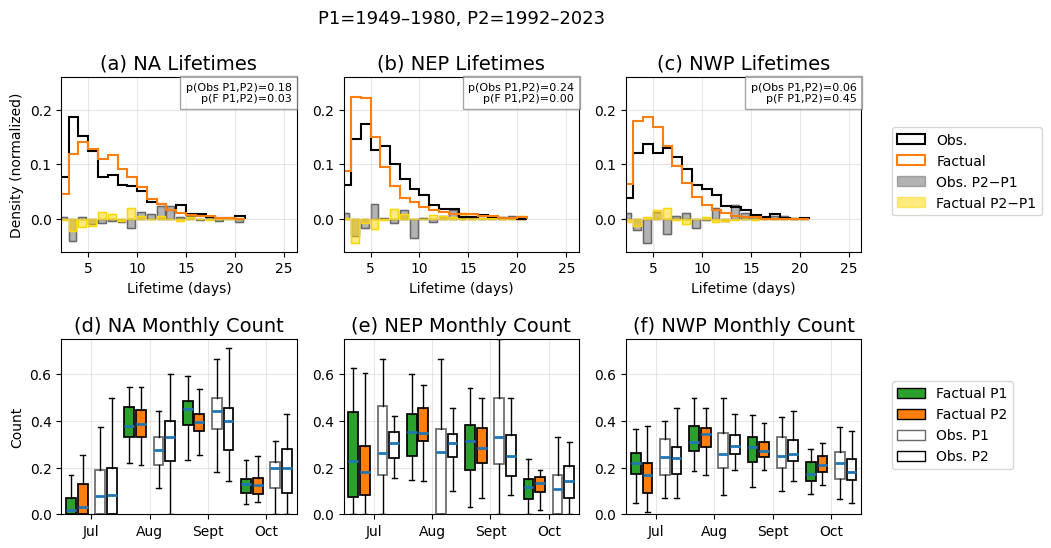

Processing Pair B: P1=1955–1985, P2=1987–2017 ...
Saved: ./figs/SI_sensitivity_pairB.png


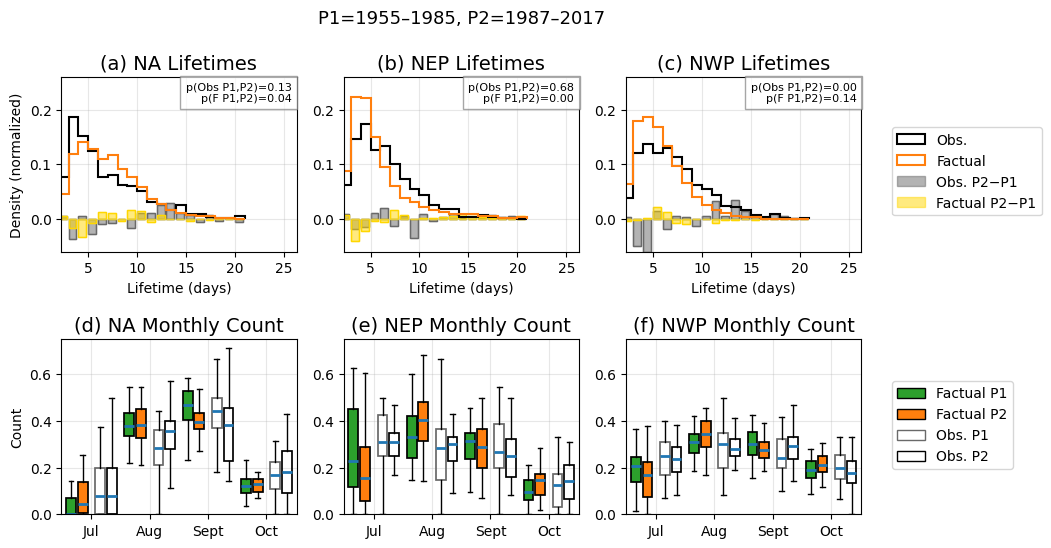

Processing Pair C: P1=1955–1980, P2=1992–2017 ...
Saved: ./figs/SI_sensitivity_pairC.png


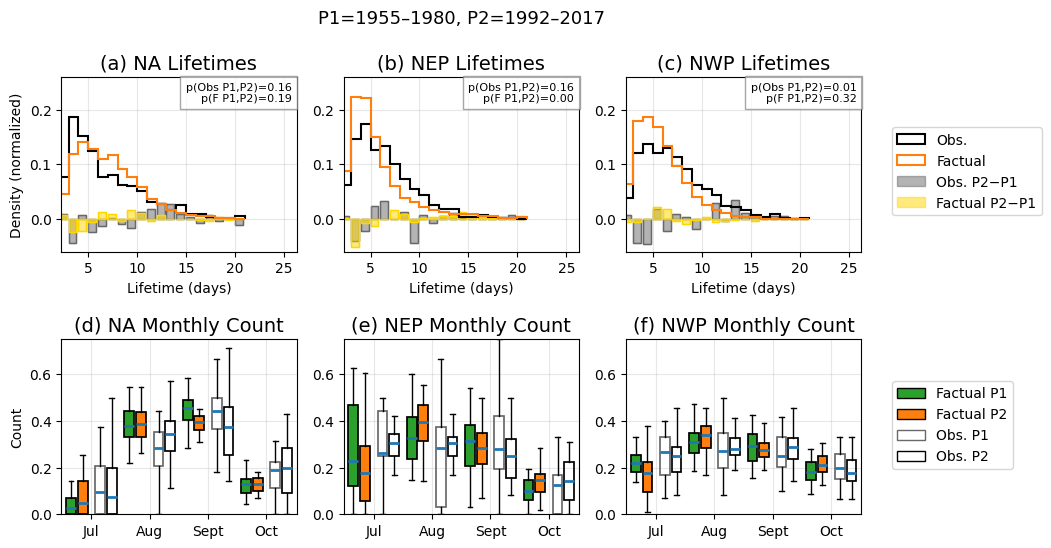

Processing Pair Z: P1=1949–1985, P2=1987–2023 ...
Saved: ./figs/SI_sensitivity_pairZ.png


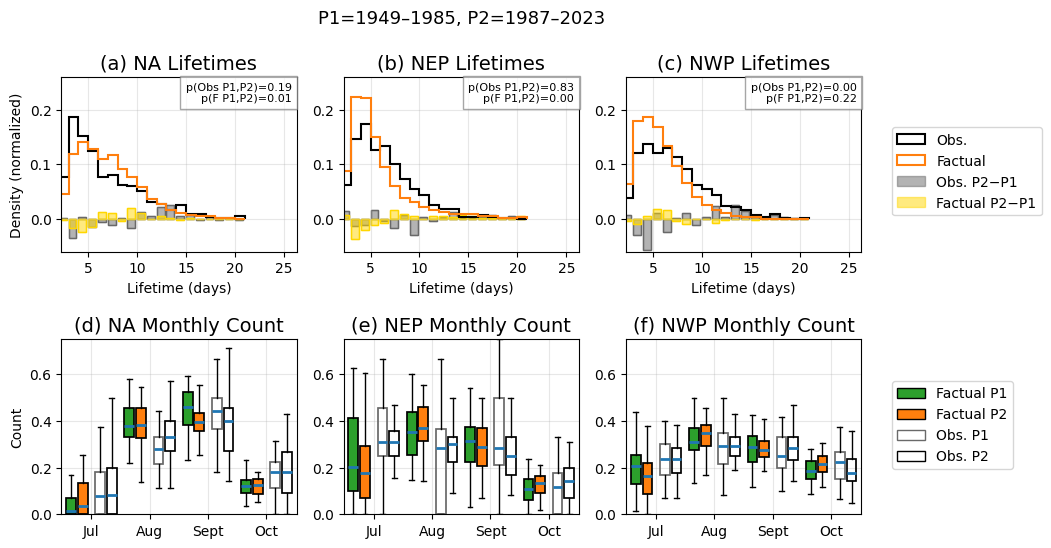

In [13]:
for pair in PERIOD_PAIRS:
    label = pair["label"]
    print(f"Processing Pair {label}: P1={pair['p1_start']}–{pair['p1_stop']}, "
          f"P2={pair['p2_start']}–{pair['p2_stop']} ...")
    d = compute_period_data(
        pair["p1_start"], pair["p1_stop"],
        pair["p2_start"], pair["p2_stop"]
    )
    make_sensitivity_figure(
        pair, d,
        save_path=f"./figs/SI_sensitivity_pair{label}.png"
    )

In [18]:
# Collect p-values from each pair run
lt_pval_rows = []
for pair in PERIOD_PAIRS:
    label = pair["label"]
    d = compute_period_data(
        pair["p1_start"], pair["p1_stop"],
        pair["p2_start"], pair["p2_stop"]
    )
    row = {
        "Pair": f"P1={pair['p1_start']}–{pair['p1_stop']}, P2={pair['p2_start']}–{pair['p2_stop']}",
        "NA (Obs.)":     round(d["lt_data"]["NA"]["p_obs"],  3),
        "NA (Factual)":  round(d["lt_data"]["NA"]["p_f"],    3),
        "NEP (Obs.)":    round(d["lt_data"]["NEP"]["p_obs"], 3),
        "NEP (Factual)": round(d["lt_data"]["NEP"]["p_f"],   3),
        "NWP (Obs.)":    round(d["lt_data"]["NWP"]["p_obs"], 3),
        "NWP (Factual)": round(d["lt_data"]["NWP"]["p_f"],   3),
    }
    lt_pval_rows.append(row)

In [19]:
df_lt_pvals = pd.DataFrame(lt_pval_rows).set_index("Pair").T
print("KS test p-values for lifetime distributions (P1 vs P2)")
df_lt_pvals

KS test p-values for lifetime distributions (P1 vs P2)


Pair,"P1=1949–1980, P2=1992–2023","P1=1955–1985, P2=1987–2017","P1=1955–1980, P2=1992–2017","P1=1949–1985, P2=1987–2023"
NA (Obs.),0.183,0.127,0.155,0.188
NA (Factual),0.033,0.035,0.194,0.006
NEP (Obs.),0.242,0.683,0.163,0.826
NEP (Factual),0.001,0.004,0.004,0.000
NWP (Obs.),0.064,0.000,0.012,0.002
NWP (Factual),0.452,0.136,0.325,0.215
